In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from skimage import io, measure
import seaborn as sb
import matplotlib.pyplot as plt

import stackview
%load_ext autoreload
%autoreload 2
dirname = Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Esophagus/1')

In [107]:
masks = io.imread(dirname/'mask_cleaned.tif')
klf4 = io.imread(dirname/'Klf4_combined.tif')

dx = 0.1892906
dz = 1

In [3]:
np.unique(masks).shape

(591,)

In [4]:
from skimage import filters as skfilters
from scipy.ndimage import filters

th = skfilters.threshold_li(klf4[57,...])
klf4_th = klf4.copy().astype(float)
klf4_th[klf4_th < th] = 0
klf4_th = filters.gaussian_filter(klf4_th,sigma=[1,1,1])

io.imsave(dirname / 'klf4_th.tif',klf4_th.astype(np.uint16))
stackview.slice(klf4_th,zoom_factor=0.3)

/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_6078/1578767578.py:7: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  klf4_th = filters.gaussian_filter(klf4_th,sigma=[1,1,1])
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Esophagus/1/klf4_th.tif is a low contrast image
  return func(*args, **kwargs)


In [116]:
def approx_basal_area(mask):
    return(mask[:3,...].sum())

def approx_apical_area(mask):
    return(mask[-3:,...].sum())

df = pd.DataFrame(measure.regionprops_table(masks,intensity_image=klf4,
                                            properties=['label','area','mean_intensity'],
                                           extra_properties=[approx_basal_area,approx_apical_area],spacing=[dz,dx,dx]))
df = df.rename(columns={'mean_intensity':'klf4 intensity','area':'Cell volume'})
df['approx_basal_area'] *= dz*dx*dx
df['approx_apical_area'] *= dz*dx*dx
df = pd.merge(df,pd.DataFrame( measure.regionprops_table(masks,intensity_image=klf4_th,
                                            properties=['mean_intensity'])),left_index=True,right_index=True)
df = df.rename(columns={'mean_intensity':'Thresholded klf4 intensity'})

<Axes: xlabel='Cell volume', ylabel='Thresholded klf4 intensity'>

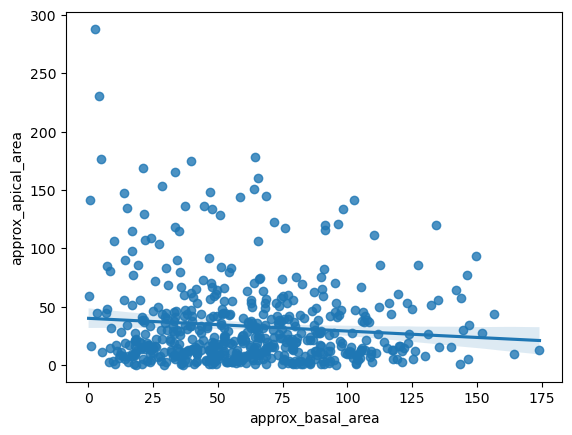

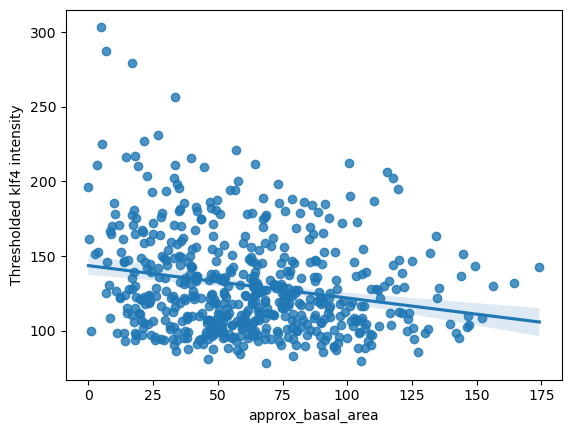

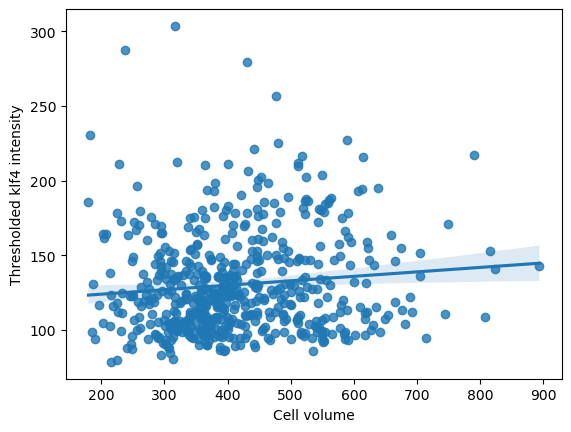

In [117]:
plt.figure()
sb.regplot(df,x='approx_basal_area',y='approx_apical_area')
plt.figure()
sb.regplot(df,x='approx_basal_area',y='Thresholded klf4 intensity')
plt.figure()
sb.regplot(df,x='Cell volume',y='Thresholded klf4 intensity')

# SpHarm

In [7]:
# Backfilter segmentation by 'valid' cells
valid_labels = set(df.label)
all_labels = set(np.unique(masks)[1:])
invalid_labels = all_labels - valid_labels
len(invalid_labels)

33

In [8]:
for l in invalid_labels:
    masks[masks == l] = 0

In [9]:
io.imsave(dirname / 'mask_cleaned.tif',masks)

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Esophagus/1/mask_cleaned.tif is a low contrast image
  return func(*args, **kwargs)


In [61]:
from measurements import estimate_sh_coefficients

spacing = [1,0.1892906,0.1892906]
cyto_params = estimate_sh_coefficients(masks, nuc_seg=None, lmax=5, spacing = spacing, return_aligned=False)

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/aicsshparam/shparam.py:134: UserWarning: Mesh centroid seems to fall outside the object. This indicates        the mesh may not be a manifold suitable for spherical harmonics        parameterization.
  warnings.warn(


In [64]:
df_pca['PC0'].min()

-4.310786108475522

In [65]:
# PCA transform

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Nuclear first

# nuc_columns = nuc_columns[df[nuc_columns].sum() > 0]
# Drop NaN columns (these are often late mitotic figures)
scaler = StandardScaler()
cyto_sph = np.array( scaler.fit_transform(cyto_params) )
pca = PCA(n_components=10)
cyto_PCA = pca.fit_transform(cyto_sph)


components = pd.DataFrame(pca.components_, columns=cyto_params.columns)

exp_var = pd.Series(pca.explained_variance_)

df_pca = pd.DataFrame(cyto_PCA,columns=[f'PC{k}' for k in range(10)])

In [66]:
from visualization import plot_cells_side_by_side, reconstruct_mesh

mean_shape = cyto_params.mean()

k = 9
max_theta = 5
min_theta = -5

reconstructed_pc_max = mean_shape + np.sqrt(exp_var.loc[k]) * components.loc[k] * max_theta
reconstructed_pc_min = mean_shape + np.sqrt(exp_var.loc[k]) * components.loc[k] * min_theta

pc0_max = {'cyto':reconstruct_mesh(reconstructed_pc_max,prefix=False)[0]}
pc0_min = {'cyto':reconstruct_mesh(reconstructed_pc_min,prefix=False)[0]}

plot_cells_side_by_side([pc0_max,pc0_min])

Widget(value='<iframe src="http://localhost:57535/index.html?ui=P_0x3b71889e0_8&reconnect=auto" class="pyvista…

In [67]:
df_merge = pd.merge(df,df_pca,left_index=True,right_index=True)
df_merge

,label,area,klf4 intensity,approx_basal_area,approx_apical_area,Thresholded klf4 intensity,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1,10036.0,117.592467,591,138,101.721375,-0.320296,1.075706,-3.828828,-1.424337,1.193422,0.934505,-1.650762,-0.205437,-1.689845,1.066086
1,2,9124.0,146.900701,1503,125,130.271837,-1.250348,-2.327081,0.153552,1.464952,0.161228,-1.248813,-1.618017,-1.450822,1.393973,0.619805
2,3,17038.0,131.234652,415,949,115.232095,-1.450153,-1.954113,0.066909,-0.639509,0.700994,-0.036970,1.654411,2.113387,-0.411531,-1.449535
3,4,18860.0,130.508908,1832,2972,113.245843,0.686195,-4.185682,-1.465936,1.889581,0.654512,2.005390,-1.703924,0.708619,1.583666,0.642827
4,5,7815.0,127.175432,468,215,110.743574,-2.488740,0.476341,0.201358,0.636995,0.242283,-0.145850,-2.276373,0.174954,-1.477265,0.930838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,1226,8654.0,114.272706,1190,494,93.558188,-0.038442,2.236823,-0.941646,-3.309199,0.780397,2.027818,-0.622938,2.236792,0.711219,-1.941889
552,1238,6444.0,115.775605,1373,322,99.172599,4.380225,4.145368,1.156191,-2.194599,2.827799,-1.097700,1.378828,1.443021,1.843274,-0.115934
553,1243,7356.0,133.476890,2092,118,116.151875,1.776965,0.580996,2.049845,0.167131,2.398059,0.800566,0.784474,3.120945,0.977193,-0.086644
554,1256,6011.0,140.735651,726,419,123.058969,-1.044878,1.337885,-1.322365,-0.523409,1.590720,-0.521952,-0.365985,1.240028,-0.361138,1.675212


In [68]:
most_correlated_pcs = pd.DataFrame([np.corrcoef(df_merge['Thresholded klf4 intensity'],df_merge[f'PC{k}'])[0,1] for k in range(10)],columns=['Correlation'],index=[f'PC{k}' for k in range(10)])
most_correlated_pcs = most_correlated_pcs.sort_values(by='Correlation')
most_correlated_pcs

,Correlation
PC8,-0.100080
PC2,-0.091662
PC5,-0.062853
PC7,-0.029045
PC9,-0.011948
PC3,-0.007712
PC6,-0.004900
PC0,0.005694
PC1,0.027215
PC4,0.055326


In [104]:
k = 1; l = 2;
X = np.linspace(-4,4,5)
Y = np.linspace(-4,4,5)

pca_grid = {(x,y): mean_shape + np.sqrt(exp_var.loc[k]) * components.loc[k] * x + mean_shape + np.sqrt(exp_var.loc[l]) * components.loc[l] * y
             for x in X for y in Y}
meshes = []
for i,y in enumerate(Y):
    for j,x in enumerate(X):
        meshes.append({'cyto':reconstruct_mesh(pca_grid[x,y],prefix=False)[0]})

plot_cells_side_by_side(meshes,num_cols=5)

Widget(value='<iframe src="http://localhost:57535/index.html?ui=P_0x3e3487470_11&reconnect=auto" class="pyvist…

<Axes: xlabel='None-A_cut', ylabel='B_cut'>

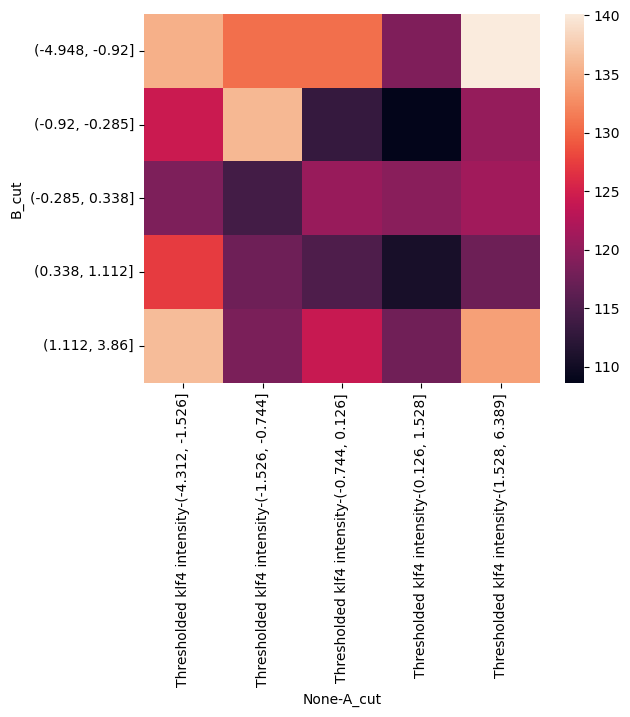

In [102]:
df_gridded = df_merge.assign(A_cut=pd.qcut(df_merge['PC0'], 5),
                             B_cut=pd.qcut(df_merge['PC8'], 5))
gridded_mean = df_gridded.groupby(['A_cut','B_cut'])['Thresholded klf4 intensity'].median().reset_index()
counts = df_gridded.groupby(['A_cut','B_cut'])['Thresholded klf4 intensity'].count().reset_index()

table = gridded_mean.pivot_table(columns='A_cut',index='B_cut')
sb.heatmap(table)

,A_cut,B_cut,Thresholded klf4 intensity
0,"(-4.312, -1.526]","(-4.948, -0.92]",134.170559
1,"(-4.312, -1.526]","(-0.92, -0.285]",133.203413
2,"(-4.312, -1.526]","(-0.285, 0.338]",121.691256
3,"(-4.312, -1.526]","(0.338, 1.112]",129.294612
4,"(-4.312, -1.526]","(1.112, 3.86]",147.164383
5,"(-1.526, -0.744]","(-4.948, -0.92]",138.443913
6,"(-1.526, -0.744]","(-0.92, -0.285]",137.921797
7,"(-1.526, -0.744]","(-0.285, 0.338]",123.385801
8,"(-1.526, -0.744]","(0.338, 1.112]",137.032833
9,"(-1.526, -0.744]","(1.112, 3.86]",120.697794


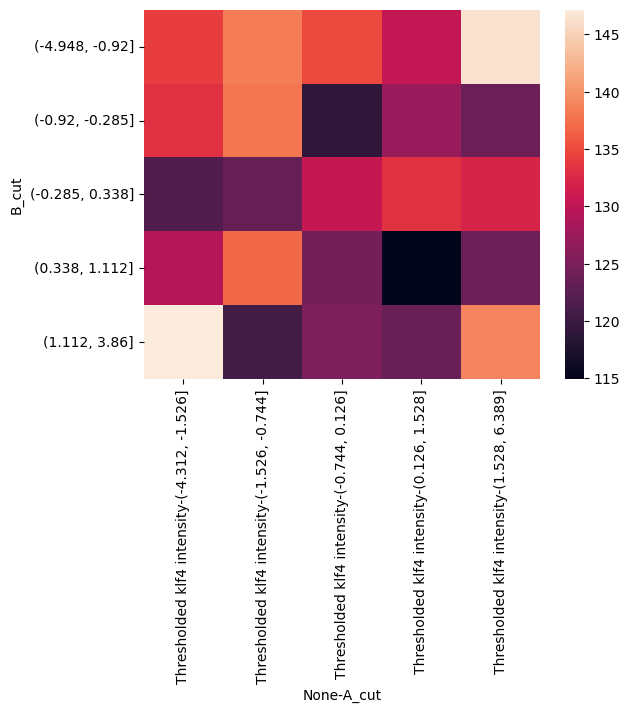

In [98]:
table = gridded_mean.pivot_table(columns='A_cut',index='B_cut',values=['Thresholded klf4 intensity'])
sb.heatmap(table)
gridded_mean